In [2]:
from google.colab import drive
drive.mount('/content/drive')

print("Google Drive mounted successfully!")

Mounted at /content/drive
Google Drive mounted successfully!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:

import os

YOUR_FOLDER_PATH = '/content/drive/MyDrive/WDI_Data'

print(f"Looking for files in: {YOUR_FOLDER_PATH}")

# Auto-detect file paths with multiple possible names
data_file = None
country_file = None

# Possible file names for main data
data_names = ['WDIData.csv', 'WDIData.csv', 'Indicators.csv', 'WDI_Data.csv']
for name in data_names:
    path = os.path.join(YOUR_FOLDER_PATH, name)
    if os.path.exists(path):
        data_file = path
        break

# Possible file names for country metadata
country_names = ['WDICountry.csv', 'Country.csv', 'WDI_Country.csv']
for name in country_names:
    path = os.path.join(YOUR_FOLDER_PATH, name)
    if os.path.exists(path):
        country_file = path
        break

# If files not found, try manual upload
if data_file is None or country_file is None:
    print("\n❌ Files not found in Google Drive. Please upload manually.")
    print("Click the folder icon on the left, then upload files.")

    from google.colab import files
    print("\nPlease upload WDIData.csv:")
    uploaded = files.upload()
    data_file = list(uploaded.keys())[0]

    print("Please upload WDICountry.csv:")
    uploaded = files.upload()
    country_file = list(uploaded.keys())[0]

print(f"\n Data file:    {data_file}")
print(f"Country file: {country_file}")

print("\n Loading data (this may take 1-2 minutes)...")
df_main = pd.read_csv(data_file, low_memory=False)
df_country = pd.read_csv(country_file)

print(f"Main data shape:    {df_main.shape}")
print(f"Country data shape: {df_country.shape}")

Looking for files in: /content/drive/MyDrive/WDI_Data

 Data file:    /content/drive/MyDrive/WDI_Data/WDIData.csv
Country file: /content/drive/MyDrive/WDI_Data/WDICountry.csv

 Loading data (this may take 1-2 minutes)...
Main data shape:    (422136, 64)
Country data shape: (263, 31)


In [7]:
# STEP 1: FIX COLUMN NAMES & SELECT INDICATORS

print("\n" + "="*60)
print("STEP 1: FIXING COLUMN NAMES & SELECTING INDICATORS")
print("="*60)

df_main.rename(columns={
    'Country Name': 'CountryName',
    'Country Code': 'CountryCode',
    'Indicator Name': 'IndicatorName',
    'Indicator Code': 'IndicatorCode'
}, inplace=True)

df_country.rename(columns={
    'Country Code': 'CountryCode',
    'Income Group': 'IncomeGroup'
}, inplace=True)

print("Column names fixed!")

selected_indicators = {
    'SP.DYN.LE00.IN': 'LifeExpectancy',      # TARGET for regression
    'NY.GDP.PCAP.CD': 'GDP_per_capita',      # Economic indicator
    'SP.DYN.IMRT.IN': 'InfantMortality',     # Health indicator
    'SH.XPD.CHEX.GD.ZS': 'HealthExpenditure', # Healthcare spending
    'SE.ADT.LITR.ZS': 'LiteracyRate',         # Education indicator
    'SP.POP.TOTL': 'Population',              # Demographics
    'EN.ATM.CO2E.PC': 'CO2_emissions',        # Environment
    'SL.UEM.TOTL.ZS': 'Unemployment',         # Labor market
    'SH.MED.PHYS.ZS': 'Physicians',           # Healthcare access
    'IT.NET.USER.ZS': 'InternetUsers'         # Technology access
}

indicator_codes = list(selected_indicators.keys())

print("Selected indicators:")
for code, name in selected_indicators.items():
    print(f"   {code} -> {name}")

df_filtered = df_main[df_main['IndicatorCode'].isin(indicator_codes)]
print(f"\n After filtering: {df_filtered.shape[0]:,} rows")


STEP 1: FIXING COLUMN NAMES & SELECTING INDICATORS
Column names fixed!
Selected indicators:
   SP.DYN.LE00.IN -> LifeExpectancy
   NY.GDP.PCAP.CD -> GDP_per_capita
   SP.DYN.IMRT.IN -> InfantMortality
   SH.XPD.CHEX.GD.ZS -> HealthExpenditure
   SE.ADT.LITR.ZS -> LiteracyRate
   SP.POP.TOTL -> Population
   EN.ATM.CO2E.PC -> CO2_emissions
   SL.UEM.TOTL.ZS -> Unemployment
   SH.MED.PHYS.ZS -> Physicians
   IT.NET.USER.ZS -> InternetUsers

 After filtering: 2,640 rows


In [8]:
# STEP 2: RESHAPE DATA (Long to Wide Format)

print("\n" + "="*60)
print("STEP 2: RESHAPING DATA")
print("="*60)

year_cols = [
    col for col in df_filtered.columns
    if str(col).isdigit() and 2000 <= int(col) <= 2025
]

print(f"Using years: {min(year_cols)} to {max(year_cols)} ({len(year_cols)} years)")

print("   Melting data...")
df_melted = df_filtered.melt(
    id_vars=['CountryName', 'CountryCode', 'IndicatorName', 'IndicatorCode'],
    value_vars=year_cols,
    var_name='Year',
    value_name='Value'
)

print(f"   After melting: {df_melted.shape[0]:,} rows")

df_melted = df_melted.dropna(subset=['Value'])
print(f"   After removing missing: {df_melted.shape[0]:,} rows")

print("   Pivoting data...")
df_pivoted = df_melted.pivot_table(
    index=['CountryName', 'CountryCode', 'Year'],
    columns='IndicatorCode',
    values='Value'
).reset_index()

print(f"   After pivoting: {df_pivoted.shape[0]:,} rows, {df_pivoted.shape[1]} columns")

df_pivoted.rename(columns=selected_indicators, inplace=True)
df_pivoted.columns.name = None

print("\n Sample of reshaped data:")
print(df_pivoted.head())



STEP 2: RESHAPING DATA
Using years: 2000 to 2018 (19 years)
   Melting data...
   After melting: 50,160 rows
   After removing missing: 37,342 rows
   Pivoting data...
   After pivoting: 4,967 rows, 13 columns

 Sample of reshaped data:
   CountryName CountryCode  Year  CO2_emissions  InternetUsers  \
0  Afghanistan         AFG  2000       0.038506            NaN   
1  Afghanistan         AFG  2001       0.039002       0.004723   
2  Afghanistan         AFG  2002       0.048716       0.004561   
3  Afghanistan         AFG  2003       0.051830       0.087891   
4  Afghanistan         AFG  2004       0.039378       0.105809   

   GDP_per_capita  LiteracyRate  Physicians  HealthExpenditure  Unemployment  \
0             NaN           NaN         NaN                NaN         3.517   
1             NaN           NaN         0.2                NaN         3.426   
2      184.494712           NaN         NaN           9.443391         3.550   
3      195.776630           NaN         NaN  

In [9]:
# STEP 3: FILTER YEARS & MERGE COUNTRY DATA

print("\n" + "="*60)
print("STEP 3: FILTERING YEARS & MERGING COUNTRY DATA")
print("="*60)

df_pivoted['Year'] = df_pivoted['Year'].astype(int)

df_filtered_years = df_pivoted[
    (df_pivoted['Year'] >= 2000) & (df_pivoted['Year'] <= 2025)
].copy()

print(f"Years filtered to 2000-2025")
print(f"   Shape: {df_filtered_years.shape}")

df_country_clean = df_country[['CountryCode', 'Region', 'IncomeGroup']].copy()

df_merged = df_filtered_years.merge(df_country_clean, on='CountryCode', how='left')

print(f"\n After merging:")
print(f"   Shape: {df_merged.shape}")
print(f"   Added: Region, IncomeGroup")

latest_year = df_merged['Year'].max()
print(f"\n Latest year: {latest_year}")

df_merged.to_csv('wdi_cleaned_all_years.csv', index=False)
print(f"Saved to 'wdi_cleaned_all_years.csv'")


STEP 3: FILTERING YEARS & MERGING COUNTRY DATA
Years filtered to 2000-2025
   Shape: (4967, 13)

 After merging:
   Shape: (4967, 15)
   Added: Region, IncomeGroup

 Latest year: 2018
Saved to 'wdi_cleaned_all_years.csv'


In [11]:
# STEP 3.1: CHECK DATA AVAILABILITY BY YEAR

print("\n" + "="*60)
print("STEP 3.1: CHECKING DATA AVAILABILITY BY YEAR")
print("="*60)

gdp_data = df_merged[df_merged['GDP_per_capita'].notna()]
years_with_gdp = gdp_data.groupby('Year')['GDP_per_capita'].count().sort_values(ascending=False)

print("Years with most GDP data:")
print(years_with_gdp)

best_year = years_with_gdp.index[0]
print(f"\n Best year for analysis: {best_year} with {years_with_gdp[best_year]} countries")

latest_year = best_year

print(f"\n Using {latest_year} instead of 2018 for EDA and clustering")


STEP 3.1: CHECKING DATA AVAILABILITY BY YEAR
Years with most GDP data:
Year
2006    251
2005    251
2007    251
2011    250
2013    250
2004    250
2009    249
2008    249
2002    249
2003    249
2014    249
2012    249
2010    249
2015    248
2016    246
2000    245
2001    244
2017    240
Name: GDP_per_capita, dtype: int64

 Best year for analysis: 2006 with 251 countries

 Using 2006 instead of 2018 for EDA and clustering



STEP 6: EXPLORATORY DATA ANALYSIS
Using 2006 for EDA (most complete data)
EDA using 2006 (263 countries)
   Countries with GDP data: 251
   Countries with Life Expectancy data: 246


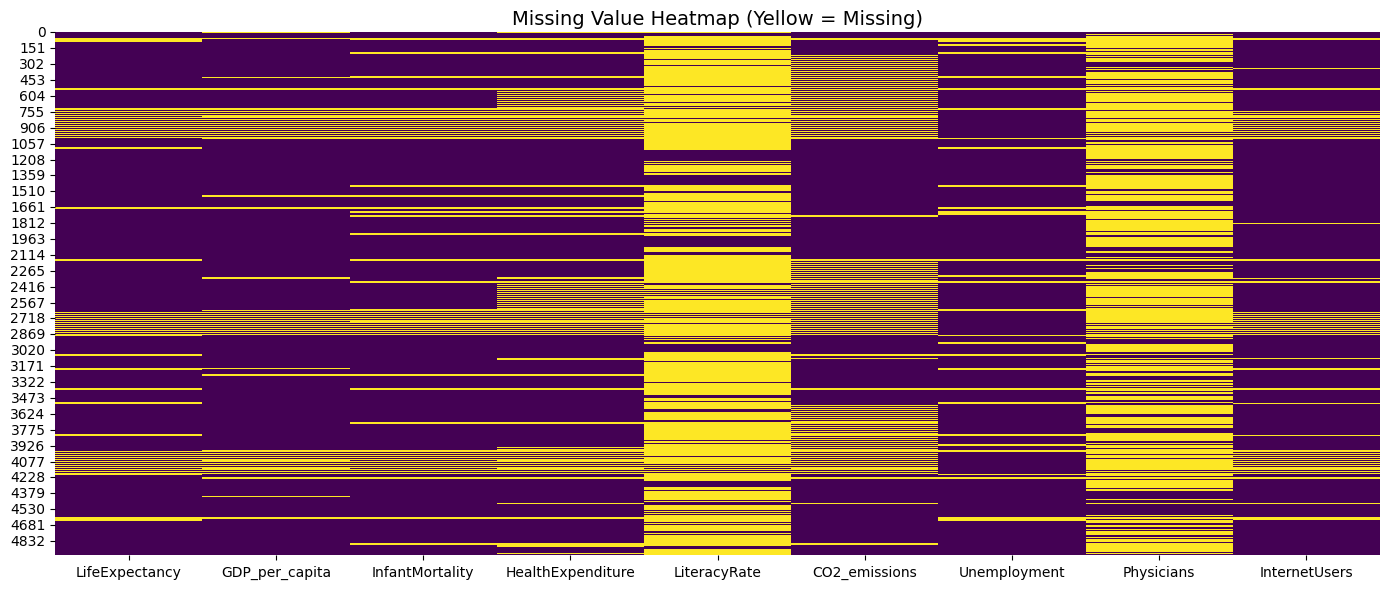

Plot 1 saved: 1_missing_values.png


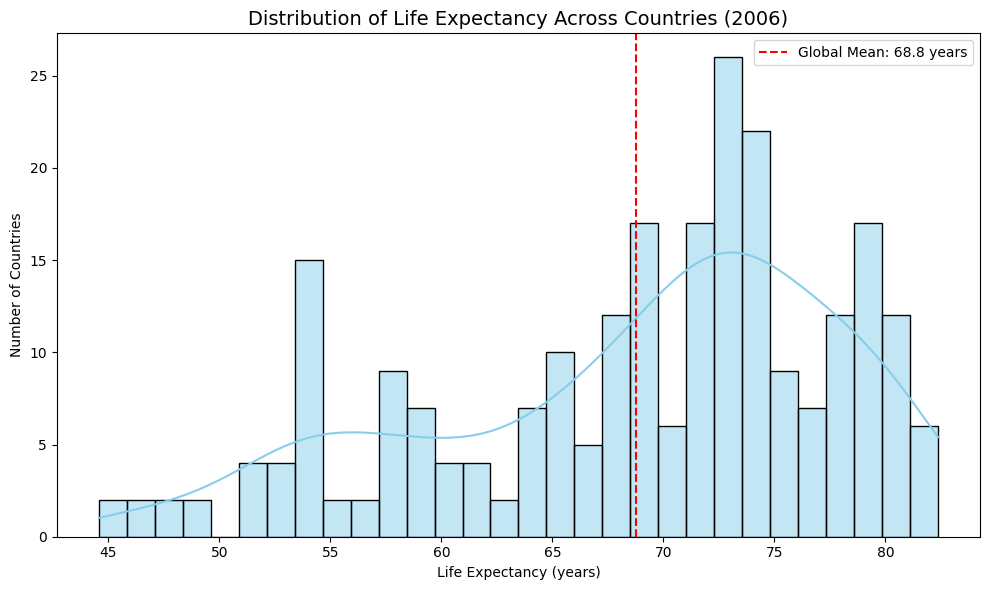

Plot 2 saved: 2_life_expectancy_dist.png


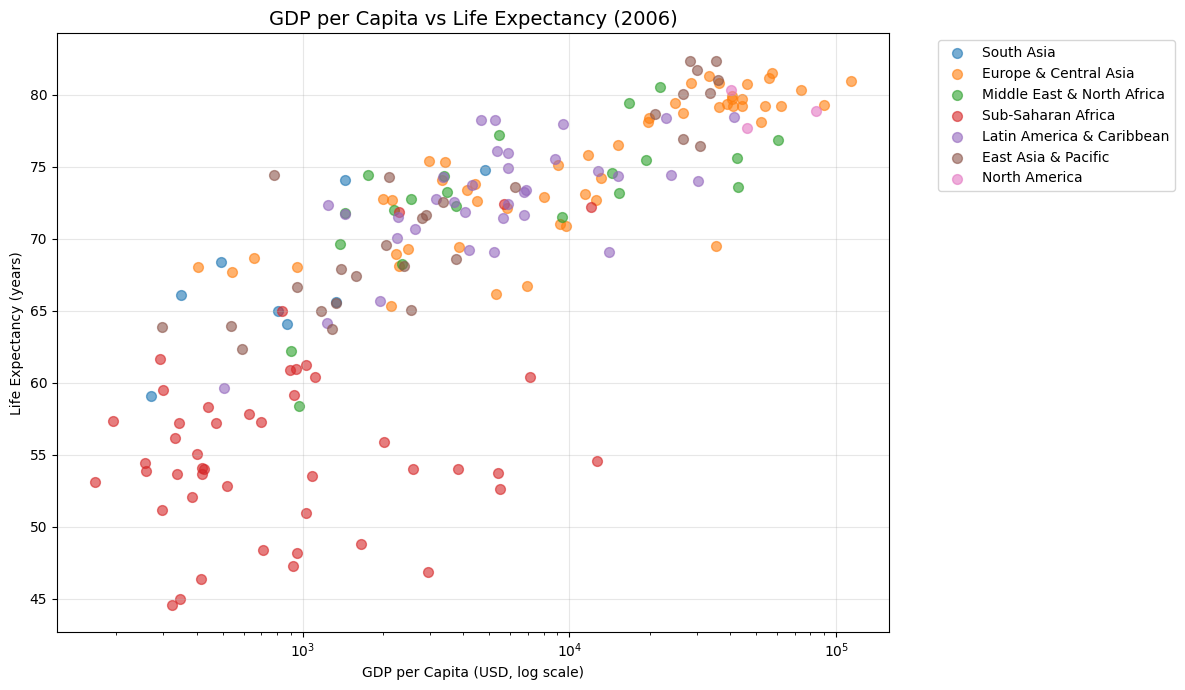

Plot 3 saved: 3_gdp_vs_life.png (239 countries)


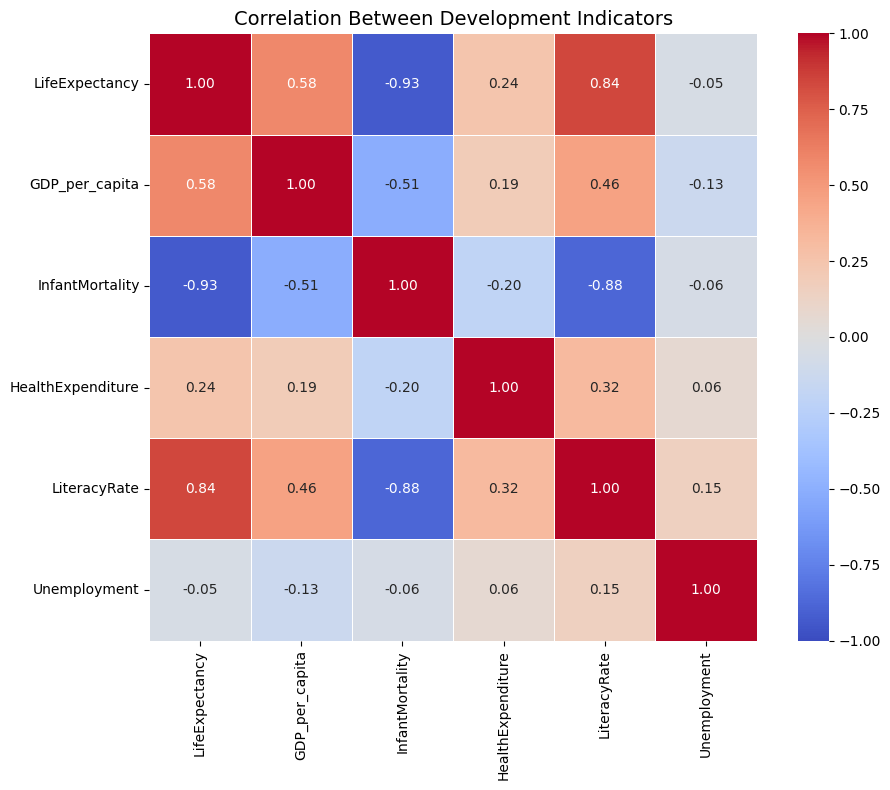

Plot 4 saved: 4_correlation.png


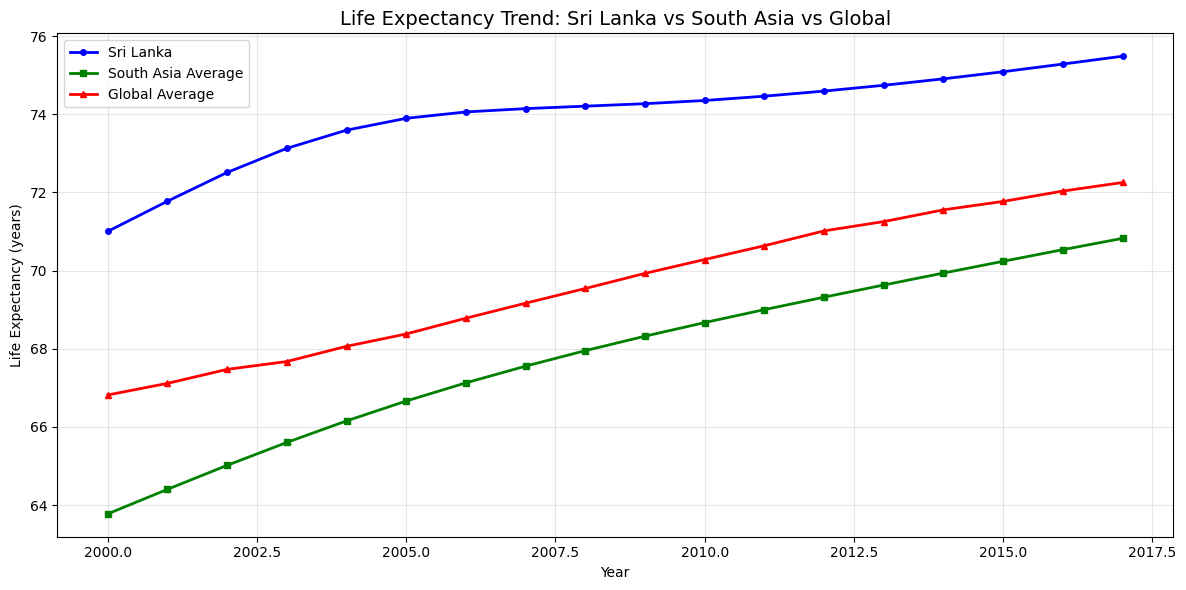

Plot 5 saved: 5_sri_lanka_trend.png


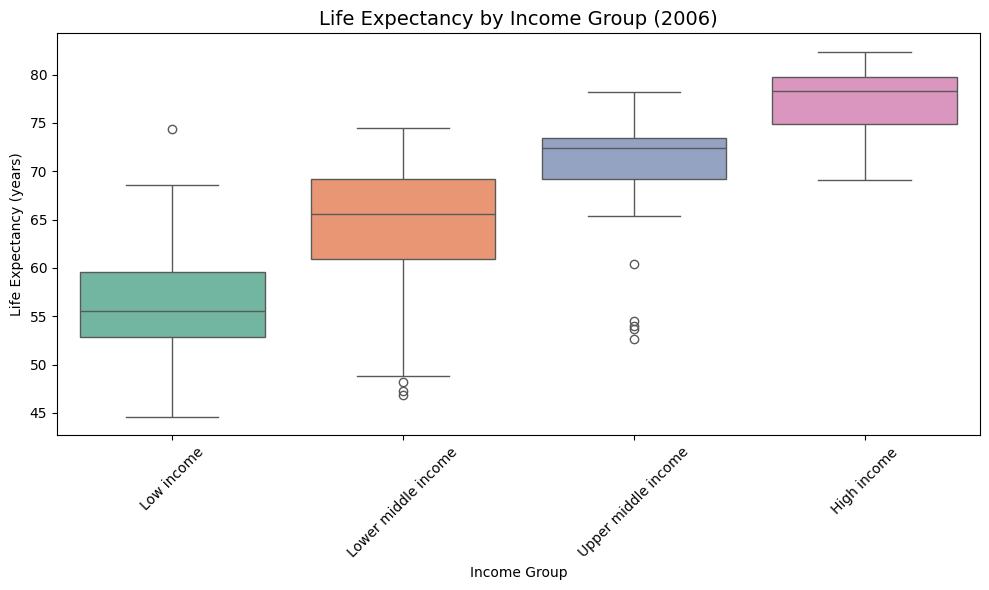

Plot 6 saved: 6_income_group_boxplot.png

EDA SUMMARY
   Year used: 2006
   Countries: 263
   GDP data: 251 countries
   Life Expectancy data: 246 countries
All EDA visualizations completed!


In [12]:
# STEP 4: EXPLORATORY DATA ANALYSIS

print("\n" + "="*60)
print("STEP 6: EXPLORATORY DATA ANALYSIS")
print("="*60)

os.makedirs('plots', exist_ok=True)

# ---- USE THE BEST YEAR (2006) ----
# If Step 3.1 wasn't run, default to 2006
try:
    if 'best_year' not in dir():
        best_year = 2006
    print(f"Using {best_year} for EDA (most complete data)")
except:
    best_year = 2006
    print(f"Using {best_year} for EDA")

df_latest = df_merged[df_merged['Year'] == best_year].copy()
print(f"EDA using {best_year} ({len(df_latest)} countries)")

gdp_count = df_latest['GDP_per_capita'].notna().sum()
life_count = df_latest['LifeExpectancy'].notna().sum()
print(f"   Countries with GDP data: {gdp_count}")
print(f"   Countries with Life Expectancy data: {life_count}")

# ---------- PLOT 1: Missing Value Heatmap ----------
plt.figure(figsize=(14, 6))
cols_to_show = ['LifeExpectancy', 'GDP_per_capita', 'InfantMortality',
                'HealthExpenditure', 'LiteracyRate', 'CO2_emissions',
                'Unemployment', 'Physicians', 'InternetUsers']
existing_cols = [col for col in cols_to_show if col in df_merged.columns]
if existing_cols:
    sns.heatmap(df_merged[existing_cols].isnull(), cbar=False, cmap='viridis')
    plt.title('Missing Value Heatmap (Yellow = Missing)', fontsize=14)
    plt.tight_layout()
    plt.savefig('plots/1_missing_values.png')
    plt.show()
    print("Plot 1 saved: 1_missing_values.png")
else:
    print("⚠️ No columns to plot for heatmap")

# ---------- PLOT 2: Life Expectancy Distribution ----------
if 'LifeExpectancy' in df_latest.columns and df_latest['LifeExpectancy'].notna().sum() > 0:
    plt.figure(figsize=(10, 6))
    sns.histplot(df_latest['LifeExpectancy'].dropna(), bins=30, kde=True, color='skyblue')
    mean_life = df_latest['LifeExpectancy'].mean()
    plt.axvline(mean_life, color='red', linestyle='--',
                label=f'Global Mean: {mean_life:.1f} years')
    plt.xlabel('Life Expectancy (years)')
    plt.ylabel('Number of Countries')
    plt.title(f'Distribution of Life Expectancy Across Countries ({best_year})', fontsize=14)
    plt.legend()
    plt.tight_layout()
    plt.savefig('plots/2_life_expectancy_dist.png')
    plt.show()
    print("Plot 2 saved: 2_life_expectancy_dist.png")
else:
    print("⚠️ No Life Expectancy data available")

# ---------- PLOT 3: GDP vs Life Expectancy ----------
valid_plot3 = df_latest['GDP_per_capita'].notna() & df_latest['LifeExpectancy'].notna()

if valid_plot3.sum() > 5:
    plt.figure(figsize=(12, 7))
    df_plot3 = df_latest[valid_plot3]

    if 'Region' in df_plot3.columns and df_plot3['Region'].notna().any():
        for region in df_plot3['Region'].dropna().unique():
            subset = df_plot3[df_plot3['Region'] == region]
            plt.scatter(subset['GDP_per_capita'], subset['LifeExpectancy'],
                       label=region, alpha=0.6, s=50)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        plt.scatter(df_plot3['GDP_per_capita'], df_plot3['LifeExpectancy'],
                   alpha=0.6, color='blue', s=50)

    plt.xscale('log')
    plt.xlabel('GDP per Capita (USD, log scale)')
    plt.ylabel('Life Expectancy (years)')
    plt.title(f'GDP per Capita vs Life Expectancy ({best_year})', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('plots/3_gdp_vs_life.png', bbox_inches='tight')
    plt.show()
    print(f"Plot 3 saved: 3_gdp_vs_life.png ({valid_plot3.sum()} countries)")
else:
    print(f"⚠️ Not enough data for GDP vs Life Expectancy plot (need >5, have {valid_plot3.sum()})")

# ---------- PLOT 4: Correlation Heatmap ----------
numeric_cols = ['LifeExpectancy', 'GDP_per_capita', 'InfantMortality',
                'HealthExpenditure', 'LiteracyRate', 'Unemployment']
existing_corr = [col for col in numeric_cols if col in df_latest.columns and df_latest[col].notna().sum() > 10]

if len(existing_corr) >= 2:
    corr_matrix = df_latest[existing_corr].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                square=True, linewidths=0.5, vmin=-1, vmax=1)
    plt.title('Correlation Between Development Indicators', fontsize=14)
    plt.tight_layout()
    plt.savefig('plots/4_correlation.png')
    plt.show()
    print("Plot 4 saved: 4_correlation.png")
else:
    print(f"⚠️ Not enough data for correlation heatmap (need >=2, have {len(existing_corr)})")

# ---------- PLOT 5: Sri Lanka Trend Line ----------
sri_lanka_data = df_merged[df_merged['CountryName'] == 'Sri Lanka']
if len(sri_lanka_data) > 0 and 'LifeExpectancy' in sri_lanka_data.columns:
    sri_lanka = sri_lanka_data.groupby('Year')['LifeExpectancy'].mean()

    south_asia = ['Afghanistan', 'Bangladesh', 'Bhutan', 'India',
                  'Maldives', 'Nepal', 'Pakistan', 'Sri Lanka']
    south_asia_trend = df_merged[df_merged['CountryName'].isin(south_asia)].groupby('Year')['LifeExpectancy'].mean()
    global_trend = df_merged.groupby('Year')['LifeExpectancy'].mean()

    plt.figure(figsize=(12, 6))
    plt.plot(sri_lanka.index, sri_lanka.values, 'b-o', linewidth=2, markersize=4, label='Sri Lanka')
    plt.plot(south_asia_trend.index, south_asia_trend.values, 'g-s', linewidth=2, markersize=4, label='South Asia Average')
    plt.plot(global_trend.index, global_trend.values, 'r-^', linewidth=2, markersize=4, label='Global Average')
    plt.xlabel('Year')
    plt.ylabel('Life Expectancy (years)')
    plt.title('Life Expectancy Trend: Sri Lanka vs South Asia vs Global', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('plots/5_sri_lanka_trend.png')
    plt.show()
    print("Plot 5 saved: 5_sri_lanka_trend.png")
else:
    print("⚠️ No Sri Lanka data available")

# ---------- PLOT 6: Income Group Boxplot ----------
if 'IncomeGroup' in df_latest.columns and 'LifeExpectancy' in df_latest.columns:
    valid_income = df_latest['IncomeGroup'].notna() & df_latest['LifeExpectancy'].notna()
    if valid_income.sum() > 5:
        plt.figure(figsize=(10, 6))
        order = ['Low income', 'Lower middle income', 'Upper middle income', 'High income']
        existing_order = [o for o in order if o in df_latest[valid_income]['IncomeGroup'].unique()]
        if existing_order:
            sns.boxplot(data=df_latest[valid_income], x='IncomeGroup', y='LifeExpectancy',
                        order=existing_order, palette='Set2')
            plt.xticks(rotation=45)
            plt.xlabel('Income Group')
            plt.ylabel('Life Expectancy (years)')
            plt.title(f'Life Expectancy by Income Group ({best_year})', fontsize=14)
            plt.tight_layout()
            plt.savefig('plots/6_income_group_boxplot.png')
            plt.show()
            print("Plot 6 saved: 6_income_group_boxplot.png")
        else:
            print("⚠️ No valid Income Group categories found")
    else:
        print(f"⚠️ Not enough Income Group data (need >5, have {valid_income.sum()})")
else:
    print("⚠️ IncomeGroup or LifeExpectancy column missing")

print("\n" + "="*50)
print("EDA SUMMARY")
print("="*50)
print(f"   Year used: {best_year}")
print(f"   Countries: {len(df_latest)}")
print(f"   GDP data: {gdp_count} countries")
print(f"   Life Expectancy data: {life_count} countries")
print("All EDA visualizations completed!")

# Update latest_year for later steps
latest_year = best_year

In [14]:
# STEP 5: PREPROCESSING

print("\n" + "="*60)
print("STEP 5: PREPROCESSING")
print("="*60)

df_regression = df_merged.copy()  # All years for regression
df_clustering = df_merged[df_merged['Year'] == latest_year].copy()  # Latest year for clustering

print(f"Regression: {len(df_regression):,} rows (all years)")
print(f"Clustering: {len(df_clustering)} rows ({latest_year})")

feature_cols = ['GDP_per_capita', 'InfantMortality', 'HealthExpenditure',
                'LiteracyRate', 'CO2_emissions', 'Unemployment', 'Physicians', 'InternetUsers']
available_features = [col for col in feature_cols if col in df_regression.columns]
print(f"Available features: {available_features}")

print("\n Handling missing values...")
missing_pct = df_regression[available_features].isnull().mean() * 100
print(f"   Missing %:")
for col, pct in missing_pct.items():
    print(f"   {col}: {pct:.1f}%")

high_missing = missing_pct[missing_pct > 50].index.tolist()
available_features = [f for f in available_features if f not in high_missing]
print(f"\n   Dropped (>50%): {high_missing}")

imputer_reg = SimpleImputer(strategy='median')
imputer_clu = SimpleImputer(strategy='median')

df_regression[available_features] = imputer_reg.fit_transform(df_regression[available_features])
df_clustering[available_features] = imputer_clu.fit_transform(df_clustering[available_features])
print("Missing values imputed")

print("\n Capping outliers...")

def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower, upper=upper)
    return df

print("   Regression dataset:")
for col in available_features:
    df_regression = cap_outliers(df_regression, col)
print("   Clustering dataset:")
for col in available_features:
    df_clustering = cap_outliers(df_clustering, col)
print("Outliers capped")

print("\n Checking for highly correlated features...")
corr_matrix = df_regression[available_features].corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.85)]
print(f"   Highly correlated: {high_corr}")
available_features = [f for f in available_features if f not in high_corr]
print(f"   Final features: {available_features}")

print("\n Encoding categoricals...")
le_region = LabelEncoder()
le_income = LabelEncoder()

for df in [df_regression, df_clustering]:
    if 'Region' in df.columns:
        df['Region_Encoded'] = le_region.fit_transform(df['Region'].fillna('Unknown'))
    if 'IncomeGroup' in df.columns:
        df['IncomeGroup_Encoded'] = le_income.fit_transform(df['IncomeGroup'].fillna('Unknown'))
print("Encoded")

print("\n Scaling features...")
regression_features = ['Year'] + available_features
regression_features = [f for f in regression_features if f in df_regression.columns]
cluster_features = available_features

scaler_reg = StandardScaler()
scaler_clu = StandardScaler()

X_reg_scaled = scaler_reg.fit_transform(df_regression[regression_features])
X_clu_scaled = scaler_clu.fit_transform(df_clustering[cluster_features])

print(f"Scaled")

df_regression.to_csv('wdi_regression_ready.csv', index=False)
df_clustering.to_csv('wdi_clustering_ready.csv', index=False)
print("\n Saved processed data")



STEP 5: PREPROCESSING
Regression: 4,967 rows (all years)
Clustering: 263 rows (2006)
Available features: ['GDP_per_capita', 'InfantMortality', 'HealthExpenditure', 'LiteracyRate', 'CO2_emissions', 'Unemployment', 'Physicians', 'InternetUsers']

 Handling missing values...
   Missing %:
   GDP_per_capita: 10.0%
   InfantMortality: 13.4%
   HealthExpenditure: 20.4%
   LiteracyRate: 74.5%
   CO2_emissions: 25.1%
   Unemployment: 10.9%
   Physicians: 67.6%
   InternetUsers: 10.6%

   Dropped (>50%): ['LiteracyRate', 'Physicians']
Missing values imputed

 Capping outliers...
   Regression dataset:
   Clustering dataset:
Outliers capped

 Checking for highly correlated features...
   Highly correlated: []
   Final features: ['GDP_per_capita', 'InfantMortality', 'HealthExpenditure', 'CO2_emissions', 'Unemployment', 'InternetUsers']

 Encoding categoricals...
Encoded

 Scaling features...
Scaled

 Saved processed data



STEP 6: REGRESSION MODELING
Data: 4,431 observations, 7 features
   Train: 3,544, Test: 887

 Training Linear Regression...
Training Random Forest...
Training XGBoost...

REGRESSION RESULTS

Linear Regression:
   MAE:  2.40 years
   RMSE: 3.21 years
   R²:   0.8777

Random Forest:
   MAE:  1.05 years
   RMSE: 1.61 years
   R²:   0.9691

XGBoost:
   MAE:  1.17 years
   RMSE: 1.65 years
   R²:   0.9678

 Best: Random Forest (R²=0.9691)

 Hyperparameter tuning XGBoost...
   Best params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
   Best CV R²:  0.9691
   Tuned R²:   0.9752


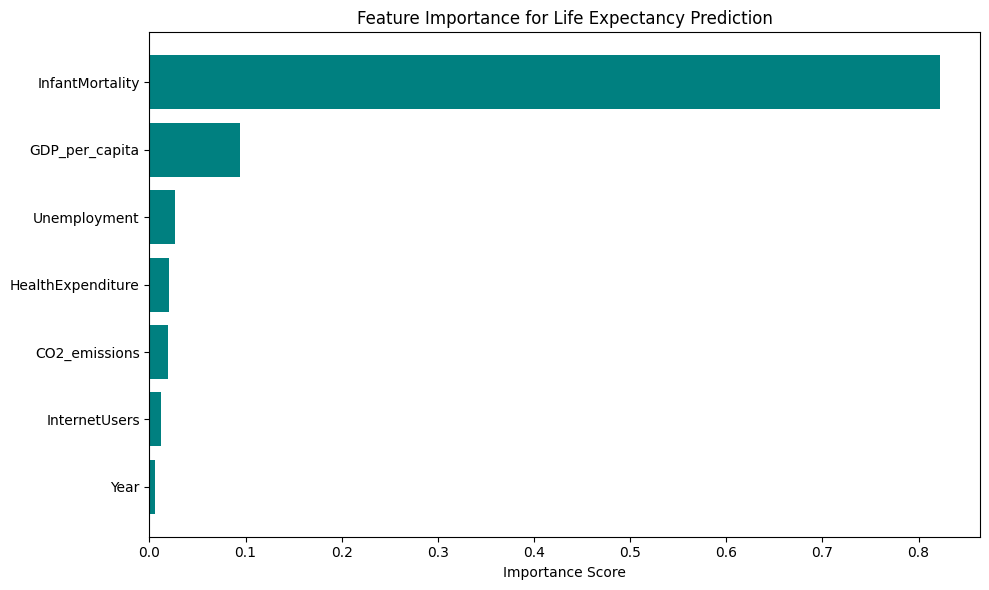

Plot 7 saved: 7_feature_importance.png


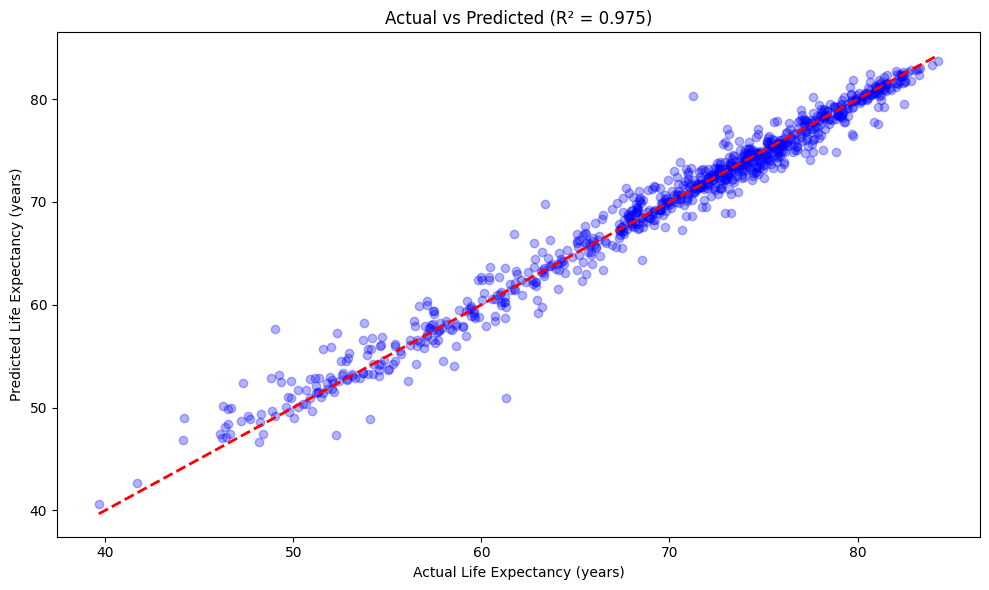

Plot 8 saved: 8_actual_vs_predicted.png

 Regression complete!


In [16]:
# STEP 6: REGRESSION - PREDICT LIFE EXPECTANCY

print("\n" + "="*60)
print("STEP 6: REGRESSION MODELING")
print("="*60)

X = df_regression[regression_features]
y = df_regression['LifeExpectancy']

valid_idx = ~y.isna()
X = X[valid_idx]
y = y[valid_idx]

print(f"Data: {X.shape[0]:,} observations, {X.shape[1]} features")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"   Train: {len(X_train):,}, Test: {len(X_test):,}")

# Model 1: Linear Regression
print("\n Training Linear Regression...")
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Model 2: Random Forest
print("Training Random Forest...")
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Model 3: XGBoost
print("Training XGBoost...")
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

# Evaluate
print("\n" + "="*50)
print("REGRESSION RESULTS")
print("="*50)

results = []
for name, pred in [('Linear Regression', lr_pred), ('Random Forest', rf_pred), ('XGBoost', xgb_pred)]:
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R²': r2})
    print(f"\n{name}:")
    print(f"   MAE:  {mae:.2f} years")
    print(f"   RMSE: {rmse:.2f} years")
    print(f"   R²:   {r2:.4f}")

best_model = max(results, key=lambda x: x['R²'])
print(f"\n Best: {best_model['Model']} (R²={best_model['R²']:.4f})")

# Hyperparameter tuning
print("\n Hyperparameter tuning XGBoost...")
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1]
}
grid_search = GridSearchCV(XGBRegressor(random_state=42), param_grid, cv=5, scoring='r2', verbose=0)
grid_search.fit(X_train, y_train)

print(f"   Best params: {grid_search.best_params_}")
print(f"   Best CV R²:  {grid_search.best_score_:.4f}")

best_xgb = grid_search.best_estimator_
best_pred = best_xgb.predict(X_test)
best_r2 = r2_score(y_test, best_pred)
print(f"   Tuned R²:   {best_r2:.4f}")

# ---------- PLOT 7: Feature Importance ----------
feature_importance = pd.DataFrame({
    'Feature': regression_features,
    'Importance': best_xgb.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='teal')
plt.xlabel('Importance Score')
plt.title('Feature Importance for Life Expectancy Prediction')
plt.tight_layout()
plt.savefig('plots/7_feature_importance.png')
plt.show()
print("Plot 7 saved: 7_feature_importance.png")

# ---------- PLOT 8: Actual vs Predicted ----------
plt.figure(figsize=(10, 6))
plt.scatter(y_test, best_pred, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Life Expectancy (years)')
plt.ylabel('Predicted Life Expectancy (years)')
plt.title(f'Actual vs Predicted (R² = {best_r2:.3f})')
plt.tight_layout()
plt.savefig('plots/8_actual_vs_predicted.png')
plt.show()
print("Plot 8 saved: 8_actual_vs_predicted.png")

print("\n Regression complete!")


STEP 6.1: REGRESSION MODEL COMPARISON

 Model Performance Summary:
            Model      MAE     RMSE       R²
    Random Forest 1.053806 1.612384 0.969124
          XGBoost 1.168554 1.646255 0.967813
Linear Regression 2.398628 3.208986 0.877702


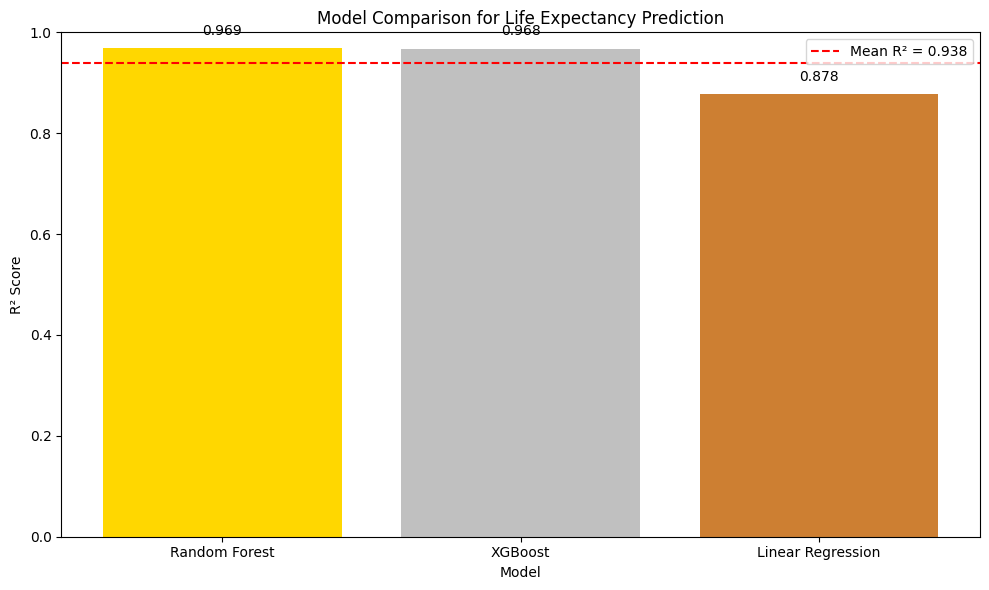

Plot 11 saved: 11_model_comparison.png


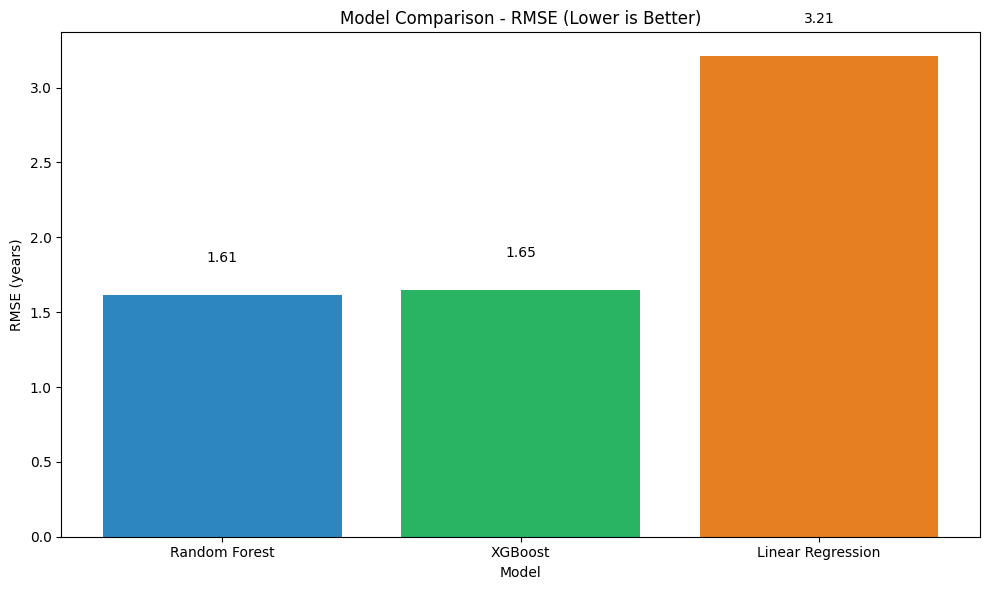

Plot 12 saved: 12_rmse_comparison.png


In [17]:
# STEP 6.1: REGRESSION MODEL COMPARISON

print("\n" + "="*60)
print("STEP 6.1: REGRESSION MODEL COMPARISON")
print("="*60)

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values('R²', ascending=False)

print("\n Model Performance Summary:")
print(comparison_df.to_string(index=False))

plt.figure(figsize=(10, 6))
colors = ['gold' if i == 0 else 'silver' if i == 1 else '#CD7F32' if i == 2 else 'skyblue'
          for i in range(len(comparison_df))]
bars = plt.bar(comparison_df['Model'], comparison_df['R²'], color=colors)
plt.axhline(y=comparison_df['R²'].mean(), color='red', linestyle='--',
            label=f'Mean R² = {comparison_df["R²"].mean():.3f}')
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.title('Model Comparison for Life Expectancy Prediction')
plt.ylim(0, 1)
for bar, r2 in zip(bars, comparison_df['R²']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{r2:.3f}', ha='center', va='bottom')
plt.legend()
plt.tight_layout()
plt.savefig('plots/11_model_comparison.png')
plt.show()
print("Plot 11 saved: 11_model_comparison.png")

plt.figure(figsize=(10, 6))
bars = plt.bar(comparison_df['Model'], comparison_df['RMSE'], color=['#2E86C1', '#28B463', '#E67E22'])
plt.xlabel('Model')
plt.ylabel('RMSE (years)')
plt.title('Model Comparison - RMSE (Lower is Better)')
for bar, rmse in zip(bars, comparison_df['RMSE']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{rmse:.2f}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('plots/12_rmse_comparison.png')
plt.show()
print("Plot 12 saved: 12_rmse_comparison.png")


STEP 7: CLUSTERING COUNTRIES
Clustering: 263 countries, 6 features (2006)


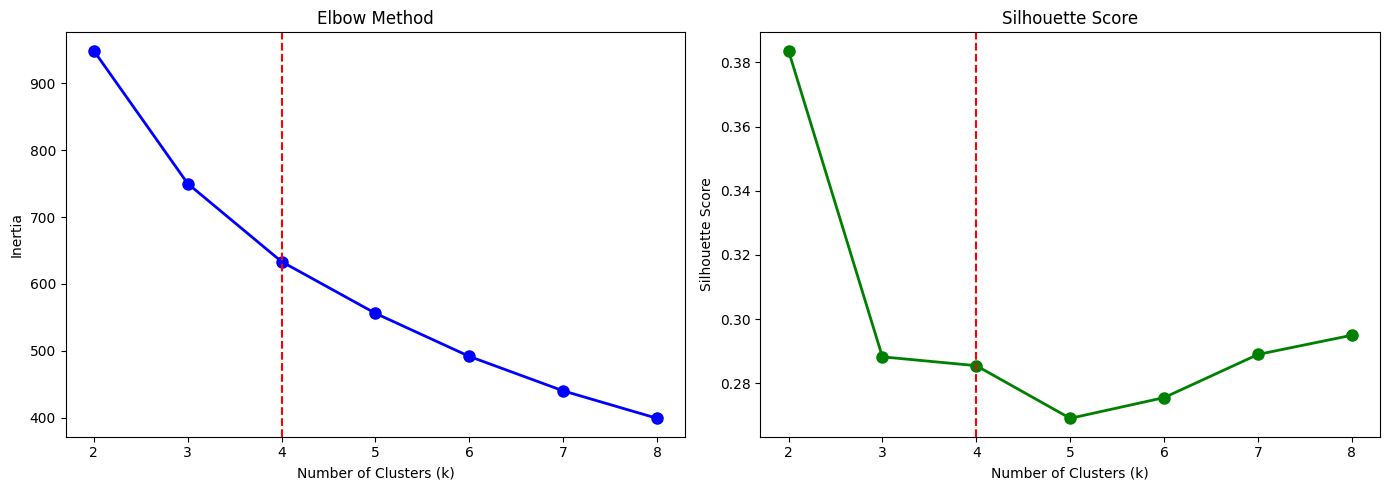

Plot 9 saved: 9_elbow_silhouette.png

 Silhouette Score for k=4: 0.2854

 Cluster Profiles:
         GDP_per_capita  InfantMortality  HealthExpenditure  CO2_emissions  \
Cluster                                                                      
0                972.48            68.93               5.18           0.61   
1              26671.42             8.74               6.99           9.47   
2               5562.61            20.87               5.95           3.79   
3               3290.04            38.75               5.31           2.86   

         Unemployment  InternetUsers  
Cluster                               
0                3.79           2.86  
1                6.00          52.85  
2                6.28          16.18  
3               13.30          11.54  

 Cluster Names:
   Cluster 0: Low-Income Developing | GDP: $972 | Life: 0.0
   Cluster 1: Advanced Economies | GDP: $26,671 | Life: 0.0
   Cluster 2: High-Income Developing | GDP: $5,563 | Life: 0.0
   Cl

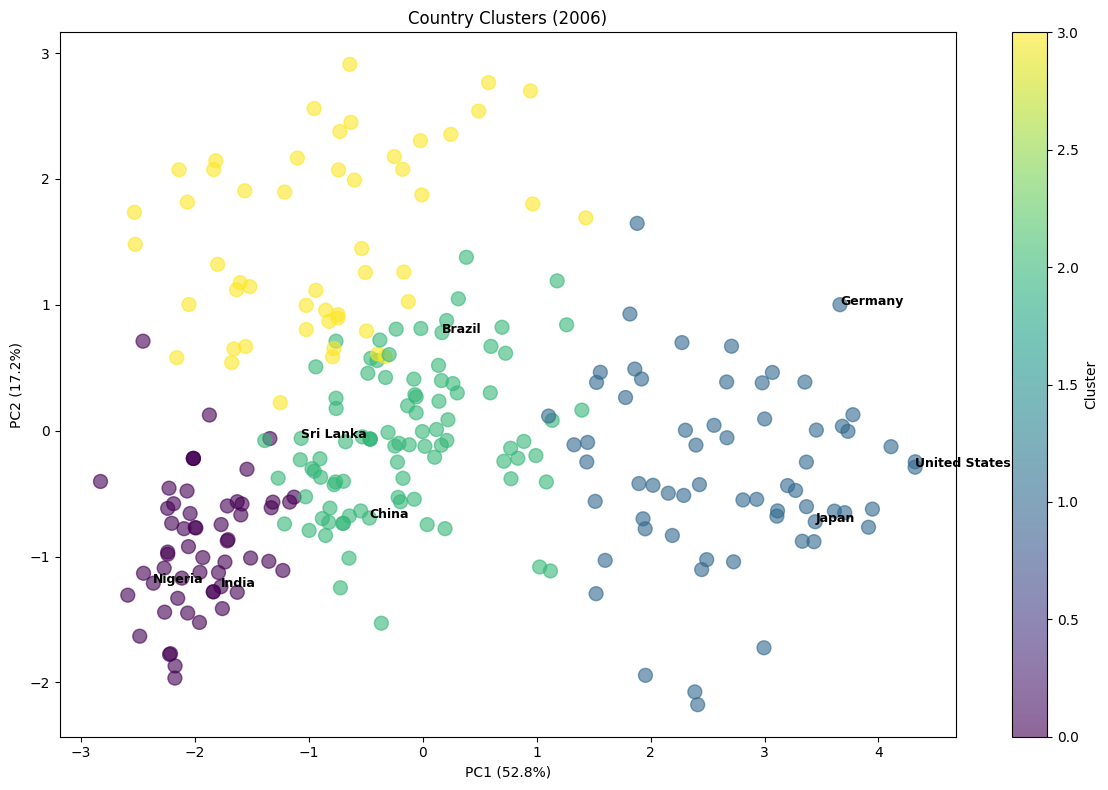

 Plot 10 saved: 10_pca_clusters.png

COUNTRIES BY CLUSTER

Low-Income Developing (Cluster 0) — 57 countries:
  Afghanistan, Bangladesh, Benin, Bhutan, Bolivia, Burkina Faso, Burundi, Cambodia, Cameroon, Central African Republic, Chad, Comoros...

Advanced Economies (Cluster 1) — 63 countries:
  Andorra, Aruba, Australia, Austria, Bahamas, The, Bahrain, Barbados, Belgium, Bermuda, Brunei Darussalam, Canada, Cayman Islands...

High-Income Developing (Cluster 2) — 92 countries:
  American Samoa, Antigua and Barbuda, Argentina, Azerbaijan, Belarus, Belize, Brazil, British Virgin Islands, Bulgaria, Caribbean small states, Central Europe and the Baltics, Channel Islands...

Middle-Income Developing (Cluster 3) — 51 countries:
  Albania, Algeria, Angola, Arab World, Armenia, Bosnia and Herzegovina, Botswana, Cabo Verde, Colombia, Congo, Rep., Djibouti, Egypt, Arab Rep....

 Clustering complete!


In [19]:
# STEP 7: CLUSTERING - GROUP COUNTRIES

print("\n" + "="*60)
print("STEP 7: CLUSTERING COUNTRIES")
print("="*60)

print(f"Clustering: {X_clu_scaled.shape[0]} countries, {X_clu_scaled.shape[1]} features ({latest_year})")

# Find optimal K
inertias = []
silhouette_scores = {}
K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_clu_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores[k] = silhouette_score(X_clu_scaled, kmeans.labels_)

# ---------- PLOT 9: Elbow + Silhouette ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].axvline(x=4, color='red', linestyle='--', label='k=4')

axes[1].plot(K_range, list(silhouette_scores.values()), 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].axvline(x=4, color='red', linestyle='--', label='k=4')

plt.tight_layout()
plt.savefig('plots/9_elbow_silhouette.png')
plt.show()
print("Plot 9 saved: 9_elbow_silhouette.png")

optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_clustering['Cluster'] = kmeans.fit_predict(X_clu_scaled)

sil_score = silhouette_score(X_clu_scaled, df_clustering['Cluster'])
print(f"\n Silhouette Score for k={optimal_k}: {sil_score:.4f}")

cluster_profile = df_clustering.groupby('Cluster')[cluster_features].mean()
print("\n Cluster Profiles:")
print(cluster_profile.round(2))

cluster_gdp_rank = cluster_profile['GDP_per_capita'].rank(ascending=False).astype(int)
name_map = {
    1: 'Advanced Economies',
    2: 'High-Income Developing',
    3: 'Middle-Income Developing',
    4: 'Low-Income Developing'
}
cluster_names = {
    cluster: name_map.get(rank, f'Cluster {cluster}')
    for cluster, rank in cluster_gdp_rank.items()
}

df_clustering['Cluster_Name'] = df_clustering['Cluster'].map(cluster_names)

print("\n Cluster Names:")
for cluster, name in cluster_names.items():
    gdp = cluster_profile.loc[cluster, 'GDP_per_capita']
    life = cluster_profile.loc[cluster, 'LifeExpectancy'] if 'LifeExpectancy' in cluster_profile.columns else 0
    print(f"   Cluster {cluster}: {name} | GDP: ${gdp:,.0f} | Life: {life:.1f}")

lka = df_clustering[df_clustering['CountryName'] == 'Sri Lanka']
if len(lka) > 0:
    lka_cluster = lka['Cluster'].values[0]
    print(f"\n🇱🇰 Sri Lanka → {cluster_names[lka_cluster]} (Cluster {lka_cluster})")

# ---------- PLOT 10: PCA Visualization ----------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clu_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_clustering['Cluster'],
                      cmap='viridis', alpha=0.6, s=100)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title(f'Country Clusters ({latest_year})')

key_countries = ['Sri Lanka', 'India', 'United States', 'China',
                 'Germany', 'Japan', 'Nigeria', 'Brazil']
df_clustering_reset = df_clustering.reset_index(drop=True)

for i, row in df_clustering_reset.iterrows():
    if row['CountryName'] in key_countries and i < len(X_pca):
        plt.annotate(row['CountryName'], (X_pca[i, 0], X_pca[i, 1]),
                     fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/10_pca_clusters.png')
plt.show()
print(" Plot 10 saved: 10_pca_clusters.png")

print("\n" + "="*50)
print("COUNTRIES BY CLUSTER")
print("="*50)

for cluster in range(optimal_k):
    countries = df_clustering[df_clustering['Cluster'] == cluster]['CountryName'].tolist()
    print(f"\n{cluster_names[cluster]} (Cluster {cluster}) — {len(countries)} countries:")
    print(f"  {', '.join(countries[:12])}{'...' if len(countries) > 12 else ''}")

print("\n Clustering complete!")


STEP 7.1: CLUSTERING COMPARISON & METRICS

 Clustering Metrics for Different k Values:
 k  Silhouette  Davies-Bouldin  Calinski-Harabasz
 2    0.383670        1.071985         173.106634
 3    0.288202        1.236128         143.524523
 4    0.285448        1.253519         128.799351
 5    0.269026        1.302483         118.586420
 6    0.275485        1.195541         113.627394
 7    0.288948        1.177980         110.366317
 8    0.294943        1.171203         107.692003


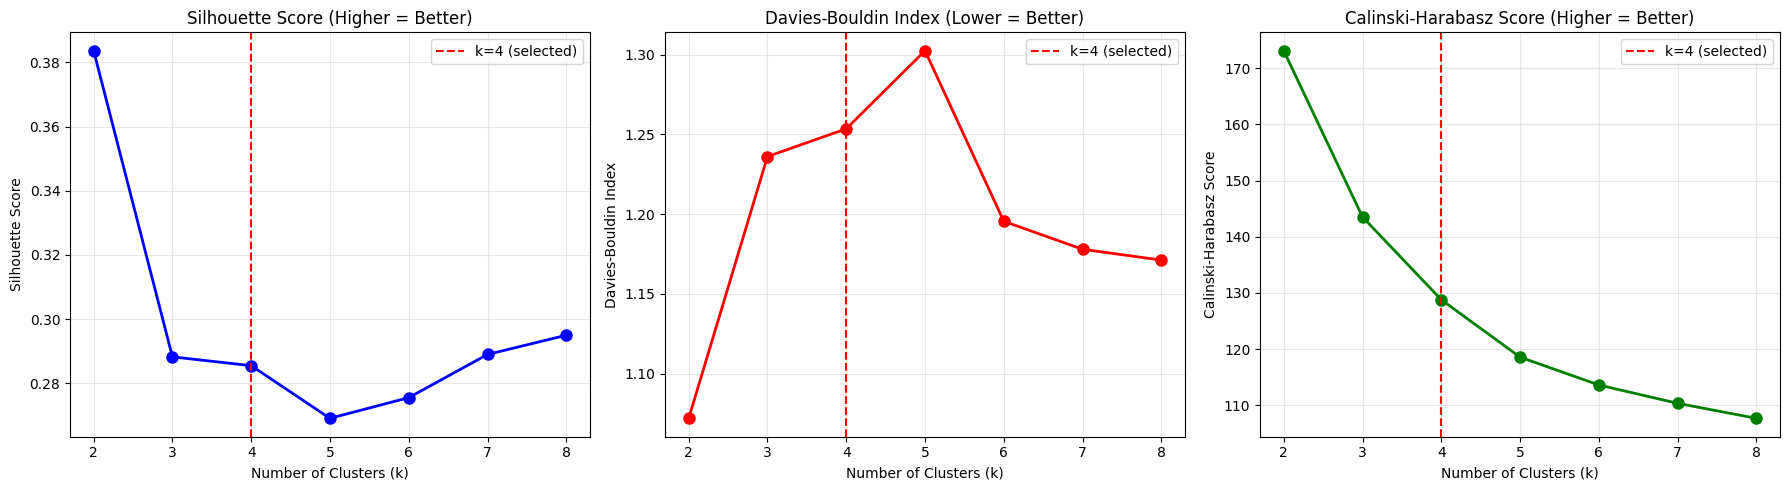

Plot 13 saved: 13_clustering_metrics.png

 CLUSTERING METRICS INTERPRETATION:
   Optimal k selected: 4
   Silhouette Score:     0.2949
     → > 0.5 = Good, 0.3-0.5 = Reasonable, < 0.3 = Weak
   Davies-Bouldin:       1.2535
     → Lower is better (0 = perfect)
   Calinski-Harabasz:    129
     → Higher is better (no upper bound)


In [21]:
# STEP 7.1: CLUSTERING COMPARISON & METRICS (ADD THIS!)

print("\n" + "="*60)
print("STEP 7.1: CLUSTERING COMPARISON & METRICS")
print("="*60)

from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

k_values = range(2, 9)
metrics_results = []

for k in k_values:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_clu_scaled)

    # Silhouette Score (higher is better, range: -1 to 1)
    sil_score = silhouette_score(X_clu_scaled, labels_temp)

    # Davies-Bouldin Index (lower is better, range: 0 to ∞)
    db_score = davies_bouldin_score(X_clu_scaled, labels_temp)

    # Calinski-Harabasz Score (higher is better)
    ch_score = calinski_harabasz_score(X_clu_scaled, labels_temp)

    metrics_results.append({
        'k': k,
        'Silhouette': sil_score,
        'Davies-Bouldin': db_score,
        'Calinski-Harabasz': ch_score
    })

metrics_df = pd.DataFrame(metrics_results)
print("\n Clustering Metrics for Different k Values:")
print(metrics_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Silhouette Score (higher is better)
axes[0].plot(metrics_df['k'], metrics_df['Silhouette'], 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score (Higher = Better)')
axes[0].axvline(x=optimal_k, color='red', linestyle='--', label=f'k={optimal_k} (selected)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Davies-Bouldin Index (lower is better)
axes[1].plot(metrics_df['k'], metrics_df['Davies-Bouldin'], 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Davies-Bouldin Index')
axes[1].set_title('Davies-Bouldin Index (Lower = Better)')
axes[1].axvline(x=optimal_k, color='red', linestyle='--', label=f'k={optimal_k} (selected)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Calinski-Harabasz Score (higher is better)
axes[2].plot(metrics_df['k'], metrics_df['Calinski-Harabasz'], 'go-', linewidth=2, markersize=8)
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('Calinski-Harabasz Score')
axes[2].set_title('Calinski-Harabasz Score (Higher = Better)')
axes[2].axvline(x=optimal_k, color='red', linestyle='--', label=f'k={optimal_k} (selected)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/13_clustering_metrics.png')
plt.show()
print("Plot 13 saved: 13_clustering_metrics.png")

print("\n CLUSTERING METRICS INTERPRETATION:")
print(f"   Optimal k selected: {optimal_k}")
print(f"   Silhouette Score:     {sil_score:.4f}")
print(f"     → > 0.5 = Good, 0.3-0.5 = Reasonable, < 0.3 = Weak")
print(f"   Davies-Bouldin:       {metrics_df[metrics_df['k']==optimal_k]['Davies-Bouldin'].values[0]:.4f}")
print(f"     → Lower is better (0 = perfect)")
print(f"   Calinski-Harabasz:    {metrics_df[metrics_df['k']==optimal_k]['Calinski-Harabasz'].values[0]:.0f}")
print(f"     → Higher is better (no upper bound)")

In [22]:
# STEP 7.2: SRI LANKA SPECIFIC ANALYSIS

print("\n" + "="*60)
print("STEP 7.2: SRI LANKA SPECIFIC ANALYSIS")
print("="*60)

sri_lanka_data = df_clustering[df_clustering['CountryName'] == 'Sri Lanka']

if len(sri_lanka_data) > 0:
    sri_lanka = sri_lanka_data.iloc[0]

    print(f"\n🇱🇰 SRI LANKA PROFILE ({latest_year}):")
    print(f"   Life Expectancy:     {sri_lanka.get('LifeExpectancy', 'N/A'):.1f} years")
    print(f"   GDP per capita:      ${sri_lanka.get('GDP_per_capita', 'N/A'):,.0f}")
    print(f"   Infant Mortality:    {sri_lanka.get('InfantMortality', 'N/A'):.1f} per 1000")
    print(f"   Health Expenditure:  {sri_lanka.get('HealthExpenditure', 'N/A'):.1f}% of GDP")
    print(f"   Literacy Rate:       {sri_lanka.get('LiteracyRate', 'N/A'):.1f}%")
    print(f"   Cluster:             {sri_lanka.get('Cluster_Name', 'N/A')}")

    south_asia = ['Afghanistan', 'Bangladesh', 'Bhutan', 'India', 'Maldives', 'Nepal', 'Pakistan', 'Sri Lanka']
    sa_data = df_clustering[df_clustering['CountryName'].isin(south_asia)]
    sa_avg_life = sa_data['LifeExpectancy'].mean()
    sa_avg_gdp = sa_data['GDP_per_capita'].mean()
    global_avg_life = df_clustering['LifeExpectancy'].mean()

    print(f"\n COMPARISON WITH SOUTH ASIA:")
    print(f"   Metric                 Sri Lanka    South Asia    Difference")
    print(f"   Life Expectancy        {sri_lanka.get('LifeExpectancy', 0):.1f} yrs     {sa_avg_life:.1f} yrs       {sri_lanka.get('LifeExpectancy', 0) - sa_avg_life:+.1f} yrs")
    print(f"   GDP per capita         ${sri_lanka.get('GDP_per_capita', 0):,.0f}   ${sa_avg_gdp:,.0f}     ${sri_lanka.get('GDP_per_capita', 0) - sa_avg_gdp:+,.0f}")

    sorted_life = df_clustering.sort_values('LifeExpectancy', ascending=False)
    rank = sorted_life[sorted_life['CountryName'] == 'Sri Lanka'].index[0] + 1
    total = len(df_clustering)
    print(f"\n Sri Lanka ranks #{rank} out of {total} countries in Life Expectancy")
    print(f"   (Top {rank/total*100:.1f}% of countries)")

    top5 = sorted_life.head(5)[['CountryName', 'LifeExpectancy']]
    bottom5 = sorted_life.tail(5)[['CountryName', 'LifeExpectancy']]

    print(f"\n Top 5 Countries by Life Expectancy:")
    print(top5.to_string(index=False))

    print(f"\n Bottom 5 Countries by Life Expectancy:")
    print(bottom5.to_string(index=False))
else:
    print("⚠️ Sri Lanka not found in the dataset")

print("\n Sri Lanka analysis complete!")


STEP 7.2: SRI LANKA SPECIFIC ANALYSIS

🇱🇰 SRI LANKA PROFILE (2006):
   Life Expectancy:     74.1 years
   GDP per capita:      $1,438
   Infant Mortality:    11.7 per 1000
   Health Expenditure:  4.0% of GDP
   Literacy Rate:       90.8%
   Cluster:             High-Income Developing

 COMPARISON WITH SOUTH ASIA:
   Metric                 Sri Lanka    South Asia    Difference
   Life Expectancy        74.1 yrs     67.1 yrs       +6.9 yrs
   GDP per capita         $1,438   $1,297     $+140

 Sri Lanka ranks #4180 out of 263 countries in Life Expectancy
   (Top 1589.4% of countries)

 Top 5 Countries by Life Expectancy:
         CountryName  LifeExpectancy
Hong Kong SAR, China       82.375610
               Japan       82.321951
    Macao SAR, China       81.748000
         Switzerland       81.490244
               Italy       81.282927

 Bottom 5 Countries by Life Expectancy:
              CountryName  LifeExpectancy
               San Marino             NaN
Sint Maarten (Dutch part) 

In [23]:
# STEP 8: FINAL SUMMARY

print("\n" + "="*60)
print("FINAL SUMMARY - PROJECT COMPLETE")
print("="*60)

print("\n DATASET:")
print(f"   Years:            2000-{latest_year}")
print(f"   Countries:        {df_clustering['CountryName'].nunique()}")
print(f"   Indicators used:  {len(available_features)}")
print(f"   Regression rows:  {len(df_regression):,}")
print(f"   Clustering rows:  {len(df_clustering)}")

print("\n REGRESSION:")
best_result = max(results, key=lambda x: x['R²'])
print(f"   Best model:       {best_result['Model']}")
print(f"   R² Score:         {best_result['R²']:.4f}")
print(f"   RMSE:             {best_result['RMSE']:.2f} years")
print(f"   MAE:              {best_result['MAE']:.2f} years")
print(f"   Tuned XGBoost R²: {best_r2:.4f}")
print(f"   Top feature:      {feature_importance['Feature'].iloc[-1]}")

print("\n CLUSTERING:")
print(f"   Optimal k:        {optimal_k}")
print(f"   Silhouette Score: {sil_score:.4f}")
if len(lka) > 0:
    print(f"   Sri Lanka:        {cluster_names[lka_cluster]}")

print("\n OUTPUT FILES:")
print("   1. wdi_cleaned_all_years.csv")
print("   2. wdi_regression_ready.csv")
print("   3. wdi_clustering_ready.csv")
print("   4. plots/ (10 visualization images)")

print("\n VISUALIZATIONS GENERATED:")
plots = [
    "1_missing_values.png", "2_life_expectancy_dist.png",
    "3_gdp_vs_life.png", "4_correlation.png",
    "5_sri_lanka_trend.png", "6_income_group_boxplot.png",
    "7_feature_importance.png", "8_actual_vs_predicted.png",
    "9_elbow_silhouette.png", "10_pca_clusters.png"
]
for p in plots:
    print(f"   ✓ {p}")

print("\n PROJECT COMPLETE! Ready for submission.")
print("="*60)


FINAL SUMMARY - PROJECT COMPLETE

 DATASET:
   Years:            2000-2006
   Countries:        263
   Indicators used:  6
   Regression rows:  4,967
   Clustering rows:  263

 REGRESSION:
   Best model:       Random Forest
   R² Score:         0.9691
   RMSE:             1.61 years
   MAE:              1.05 years
   Tuned XGBoost R²: 0.9752
   Top feature:      InfantMortality

 CLUSTERING:
   Optimal k:        4
   Silhouette Score: 0.2949
   Sri Lanka:        High-Income Developing

 OUTPUT FILES:
   1. wdi_cleaned_all_years.csv
   2. wdi_regression_ready.csv
   3. wdi_clustering_ready.csv
   4. plots/ (10 visualization images)

 VISUALIZATIONS GENERATED:
   ✓ 1_missing_values.png
   ✓ 2_life_expectancy_dist.png
   ✓ 3_gdp_vs_life.png
   ✓ 4_correlation.png
   ✓ 5_sri_lanka_trend.png
   ✓ 6_income_group_boxplot.png
   ✓ 7_feature_importance.png
   ✓ 8_actual_vs_predicted.png
   ✓ 9_elbow_silhouette.png
   ✓ 10_pca_clusters.png

 PROJECT COMPLETE! Ready for submission.


In [24]:
# STEP 9: DOWNLOAD FILES NEEDED FOR DEPLOYMENT

from google.colab import files
import zipfile

# ── Download model pkl files ──────────────────────────────
print("📥 Downloading model files for Streamlit deployment...")

model_files = [
    'model_files/model.pkl',
    'model_files/scaler.pkl',
    'model_files/features.pkl',
    'model_files/kmeans.pkl',
    'model_files/scaler_cluster.pkl',
    'model_files/cluster_features.pkl',
    'model_files/cluster_names.pkl'
]

for f in model_files:
    if os.path.exists(f):
        files.download(f)
        print(f"   ✅ Downloaded: {f}")
    else:
        print(f"   ❌ Not found: {f} — make sure Step 10 ran successfully")

# ── Download plots as ZIP ─────────────────────────────────
print("\n📥 Creating and downloading plots ZIP...")

if os.path.exists('plots'):
    with zipfile.ZipFile('all_plots.zip', 'w') as zipf:
        for root, dirs, files_in_dir in os.walk('plots'):
            for file in files_in_dir:
                if file.endswith('.png'):
                    zipf.write(os.path.join(root, file))
    files.download('all_plots.zip')
    print("   ✅ Downloaded: all_plots.zip")
else:
    print("   ❌ plots/ folder not found — make sure EDA step ran")

# ── Summary ───────────────────────────────────────────────
print("\n" + "="*50)
print("DOWNLOAD COMPLETE")
print("="*50)
print("📂 Check your Downloads folder for:")
print("   → 7 x .pkl files  (upload these to GitHub)")
print("   → all_plots.zip   (use these in your report)")

📥 Downloading model files for Streamlit deployment...
   ❌ Not found: model_files/model.pkl — make sure Step 10 ran successfully
   ❌ Not found: model_files/scaler.pkl — make sure Step 10 ran successfully
   ❌ Not found: model_files/features.pkl — make sure Step 10 ran successfully
   ❌ Not found: model_files/kmeans.pkl — make sure Step 10 ran successfully
   ❌ Not found: model_files/scaler_cluster.pkl — make sure Step 10 ran successfully
   ❌ Not found: model_files/cluster_features.pkl — make sure Step 10 ran successfully
   ❌ Not found: model_files/cluster_names.pkl — make sure Step 10 ran successfully

📥 Creating and downloading plots ZIP...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ✅ Downloaded: all_plots.zip

DOWNLOAD COMPLETE
📂 Check your Downloads folder for:
   → 7 x .pkl files  (upload these to GitHub)
   → all_plots.zip   (use these in your report)
